# Лабораторная работа №3
## Цепи Маркова с дискретным временем и модель одноканальной системы массового обслуживания

Бирюкова Екатерина

ИУ5-81Б

---

## **Содержание**

### **ЧАСТЬ 1. Модель деградации сервера с профилактикой и восстановлением**
1. Постановка задачи  
2. Выбор параметров и матрицы переходов  
3. Построение графа состояний  
4. Аналитическое исследование марковской цепи  
5. Вероятности состояний через 2, 4 и 8 недель  
6. Вероятность безотказной работы за 8 недель  
7. Среднее время до отказа  
8. Имитационное моделирование  
9. Сравнение модели с профилактикой и без профилактики

### **ЧАСТЬ 2. Модель одноканальной системы массового обслуживания**
1. Постановка задачи  
2. Выбор параметров системы  
3. Теоретический анализ режима 1  
4. Теоретический анализ режима 2  
5. Экспериментальное исследование в пакете `queueing`  
6. Сравнение аналитических и экспериментальных результатов  

### Вывод

In [ ]:
if (!require(expm)) install.packages("expm", repos = "https://cloud.r-project.org")
if (!require(markovchain)) install.packages("markovchain", repos = "https://cloud.r-project.org")
if (!require(igraph)) install.packages("igraph", repos = "https://cloud.r-project.org")
if (!require(diagram)) install.packages("diagram", repos = "https://cloud.r-project.org")
if (!require(queueing)) install.packages("queueing", repos = "https://cloud.r-project.org")
if (!require(ggplot2)) install.packages("ggplot2", repos = "https://cloud.r-project.org")
if (!require(dplyr)) install.packages("dplyr", repos = "https://cloud.r-project.org")

library(expm)
library(markovchain)
library(igraph)
library(diagram)
library(queueing)
library(ggplot2)
library(dplyr)

options(digits = 6)
set.seed(123)

Loading required package: markovchain

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘markovchain’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RcppParallel’, ‘RcppArmadillo’


Loading required package: igraph


Attaching package: ‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Loading required package: diagram

Loading required package: shape

Loading required package: queueing

Package:  markovchain
Version:  0.10.3
Date:     2026-02-02 06:30:37 UTC
BugReport: https://github.com/spedygiorgio/markovchain/issues




---
# **ЧАСТЬ 1. МОДЕЛЬ ДЕГРАДАЦИИ СЕРВЕРА С ПРОФИЛАКТИКОЙ И ВОССТАНОВЛЕНИЕМ**
---

## 1. Постановка задачи

Рассматривается дискретная марковская цепь, описывающая изменение технического состояния главного сервера вычислительного центра. Шаг времени составляет одну неделю. Система может находиться в одном из шести состояний:

- $S_1$ — отличное состояние;
- $S_2$ — хорошее состояние;
- $S_3$ — удовлетворительное состояние;
- $S_4$ — критическое состояние;
- $S_5$ — профилактика;
- $S_6$ — отказ.

Требуется:

1. Задать матрицу переходных вероятностей между состояниями.
2. Построить граф состояний системы.
3. Найти вероятности состояний системы через 2, 4 и 8 недель.
4. Вычислить вероятность безотказной работы сервера за 8 недель.
5. Определить среднее время до отказа.
6. Выполнить имитационное моделирование работы системы.
7. Сравнить результаты для модели с профилактикой и для модели без профилактики.

---
## 2. Выбор параметров и матрицы переходов

Так как конкретный вариант не задан, построим собственную модель деградации сервера. Будем считать, что:

- в хорошем состоянии сервер с высокой вероятностью сохраняет своё состояние;
- по мере ухудшения состояния возрастает вероятность перехода в более тяжёлые состояния и в отказ;
- профилактика позволяет вернуть сервер в почти новое состояние;
- состояние отказа является поглощающим.

Примем следующую матрицу переходных вероятностей:
$$
P =
\begin{pmatrix}
0.72 & 0.20 & 0.08 & 0    & 0    & 0 \\
0    & 0.58 & 0.27 & 0.15 & 0    & 0 \\
0    & 0    & 0.40 & 0.20 & 0.25 & 0.15 \\
0    & 0    & 0    & 0.25 & 0.30 & 0.45 \\
0.85 & 0.15 & 0    & 0    & 0    & 0 \\
0    & 0    & 0    & 0    & 0    & 1
\end{pmatrix}
$$

Начальное состояние системы считаем равным $S_1$:
$$
\pi_0 = (1, 0, 0, 0, 0, 0).
$$

In [ ]:
states <- c("S1", "S2", "S3", "S4", "S5", "S6")

P <- matrix(c(
  0.72, 0.20, 0.08, 0.00, 0.00, 0.00,
  0.00, 0.58, 0.27, 0.15, 0.00, 0.00,
  0.00, 0.00, 0.40, 0.20, 0.25, 0.15,
  0.00, 0.00, 0.00, 0.25, 0.30, 0.45,
  0.85, 0.15, 0.00, 0.00, 0.00, 0.00,
  0.00, 0.00, 0.00, 0.00, 0.00, 1.00
), nrow = 6, byrow = TRUE)

colnames(P) <- states
rownames(P) <- states

pi0 <- c(1, 0, 0, 0, 0, 0)
names(pi0) <- states

P
pi0

,S1,S2,S3,S4,S5,S6
S1,0.72,0.20,0.08,0.00,0.00,0.00
S2,0.00,0.58,0.27,0.15,0.00,0.00
S3,0.00,0.00,0.40,0.20,0.25,0.15
S4,0.00,0.00,0.00,0.25,0.30,0.45
S5,0.85,0.15,0.00,0.00,0.00,0.00
S6,0.00,0.00,0.00,0.00,0.00,1.00


S1 S2 S3 S4 S5 S6 
 1  0  0  0  0  0

---
## 3. Проверка корректности матрицы переходов
---

Для корректно заданной матрицы переходов марковской цепи сумма элементов в каждой строке должна быть равна единице. Проверим это условие для построенной матрицы.

In [ ]:
row_sums <- rowSums(P)
row_sums

S1 S2 S3 S4 S5 S6 
 1  1  1  1  1  1

По результатам проверки видно, что сумма вероятностей в каждой строке равна единице. Следовательно, матрица переходов задана корректно и может использоваться для дальнейшего анализа.

---
## 4. Построение графа состояний

Построим граф состояний марковской цепи. Вершины графа соответствуют состояниям системы, а дуги — возможным переходам между состояниями с ненулевыми вероятностями.

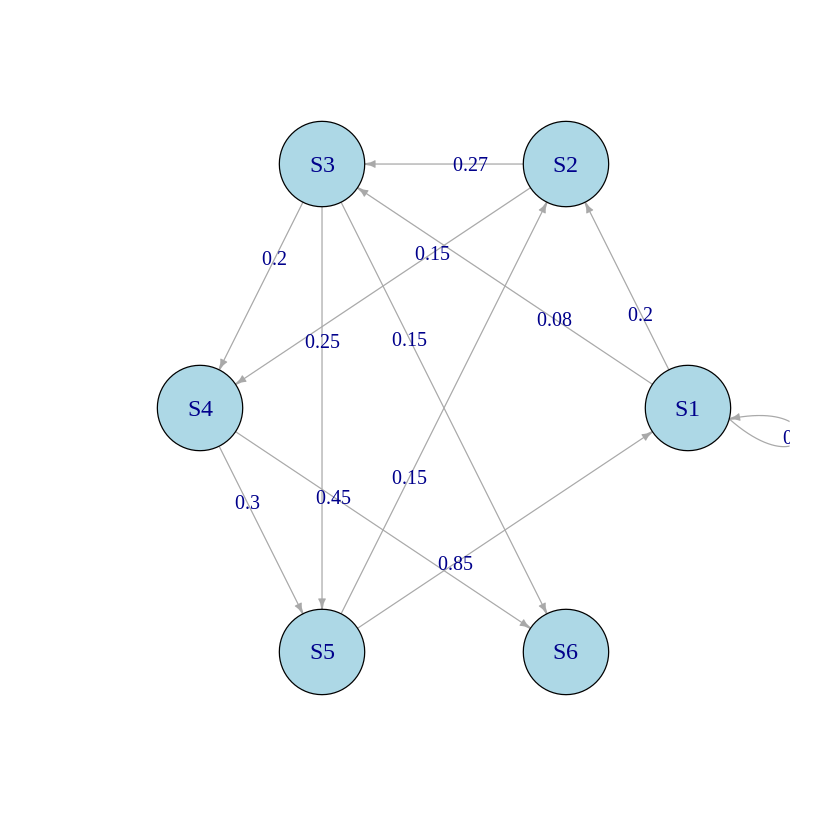

In [ ]:
edges <- which(P > 0, arr.ind = TRUE)
edge_list <- data.frame(
  from = rownames(P)[edges[, 1]],
  to   = colnames(P)[edges[, 2]],
  prob = P[edges]
)

g <- graph_from_data_frame(edge_list, directed = TRUE, vertices = states)

plot(
  g,
  edge.label = round(edge_list$prob, 2),
  vertex.size = 35,
  vertex.color = "lightblue",
  vertex.label.cex = 1.2,
  edge.arrow.size = 0.4,
  layout = layout_in_circle
)

Полученный граф наглядно отражает возможные переходы между состояниями сервера. Состояние $S_6$ является поглощающим, так как после отказа система остаётся в этом состоянии с вероятностью 1.

---
## 5. Аналитическое исследование марковской цепи

Для нахождения распределения вероятностей состояний через $n$ шагов используется формула:
$$
\pi_n = \pi_0 P^n,
$$
где $\pi_0$ — начальный вектор вероятностей, а $P$ — матрица переходов.

Вычислим вероятности состояний системы через 2, 4 и 8 недель.

In [ ]:
state_distribution <- function(n, P, pi0) {
  as.numeric(pi0 %*% (P %^% n))
}

pi2 <- state_distribution(2, P, pi0)
pi4 <- state_distribution(4, P, pi0)
pi8 <- state_distribution(8, P, pi0)

distributions <- data.frame(
  state = states,
  `2 недели` = pi2,
  `4 недели` = pi4,
  `8 недель` = pi8
)

distributions

state,X2.недели,X4.недели,X8.недель
<chr>,<dbl>,<dbl>,<dbl>
S1,0.5184,0.3232236,0.2316348
S2,0.2600,0.2348430,0.1599405
S3,0.1436,0.1683842,0.1188501
S4,0.0460,0.0922494,0.0717137
S5,0.0200,0.0660440,0.0560450
S6,0.0120,0.1152558,0.3618158


Полученная таблица показывает, как со временем перераспределяется вероятность между состояниями сервера. По мере роста числа шагов увеличивается вероятность нахождения системы в состояниях деградации и в состоянии отказа.

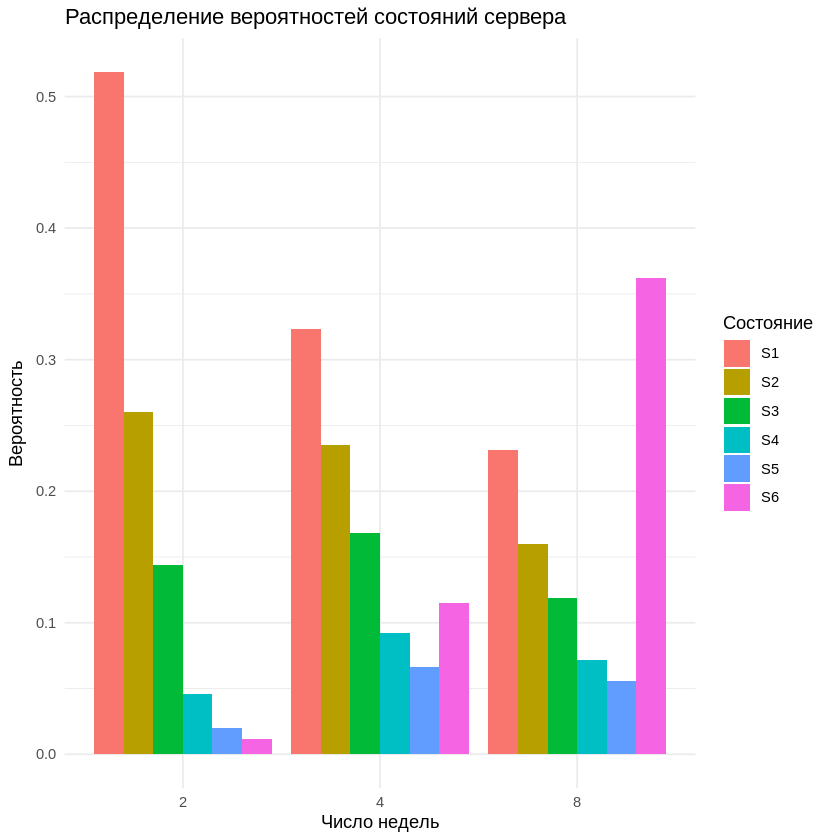

In [ ]:
plot_df <- data.frame(
  week = rep(c(2, 4, 8), each = length(states)),
  state = rep(states, times = 3),
  probability = c(pi2, pi4, pi8)
)

ggplot(plot_df, aes(x = factor(week), y = probability, fill = state)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Распределение вероятностей состояний сервера",
    x = "Число недель",
    y = "Вероятность",
    fill = "Состояние"
  ) +
  theme_minimal()

---
## 6. Вероятность безотказной работы за 8 недель

Под безотказной работой будем понимать событие, при котором к моменту 8-й недели система не перешла в состояние отказа $S_6$. Тогда вероятность безотказной работы равна сумме вероятностей состояний $S_1$–$S_5$ через 8 недель:
$$
P_{\text{безотк}}(8) = 1 - P\{S_6 \text{ на 8-й неделе}\}.
$$

In [ ]:
p_fail_8 <- pi8[6]

p_work_8 <- 1 - p_fail_8

cat("Вероятность отказа за 8 недель:", round(p_fail_8, 4), "\n")
cat("Вероятность безотказной работы за 8 недель:", round(p_work_8, 4), "\n")

Вероятность отказа за 8 недель: 0.3618 
Вероятность безотказной работы за 8 недель: 0.6382 


## 7. Среднее время до отказа
---

Для вычисления среднего времени до отказа используем аппарат поглощающих марковских цепей.

Состояние $S_6$ является поглощающим. Выделим подматрицу $Q$, соответствующую непоглощающим состояниям $S_1$–$S_5$. Тогда фундаментальная матрица определяется как:
$$
N = (I - Q)^{-1}.
$$

Среднее время до поглощения (отказа) равно сумме элементов первой строки матрицы $N$, так как начальное состояние — $S_1$.

In [ ]:
Q <- P[1:5, 1:5]

I <- diag(5)

N <- solve(I - Q)

mttf <- sum(N[1, ])

N
mttf

,S1,S2,S3,S4,S5
S1,6.73817,3.58121,2.509967,1.38557,1.043162
S2,3.07202,4.20523,2.301959,1.45490,1.011960
S3,3.40354,2.02115,3.029988,1.21223,1.121165
S4,2.47530,1.46993,0.991506,1.89172,0.815393
S5,6.18825,3.67481,2.478766,1.39597,2.038482


[1] 15.2581

Полученное значение соответствует среднему числу недель до отказа сервера при начальном состоянии $S_1$.

## 8. Имитационное моделирование
---

Выполним имитационное моделирование работы системы. Будем многократно моделировать процесс до момента попадания в состояние отказа $S_6$ и оценим среднее время до отказа.

In [ ]:
simulate_run <- function(P, start_state = 1, max_steps = 1000) {
  state <- start_state
  steps <- 0

  while (state != 6 && steps < max_steps) {
    state <- sample(1:6, size = 1, prob = P[state, ])
    steps <- steps + 1
  }

  return(steps)
}

n_sim <- 5000
sim_results <- replicate(n_sim, simulate_run(P))

mean_sim <- mean(sim_results)

mean_sim

[1] 14.929

Среднее время до отказа, полученное методом имитационного моделирования, близко к аналитическому значению, что подтверждает корректность модели.

## 9. Сравнение модели с профилактикой и без профилактики
---

Рассмотрим модель без состояния профилактики $S_5$. Для этого перераспределим вероятности переходов в $S_5$ в сторону улучшения состояния (в $S_1$).

In [ ]:
P_no5 <- P

P_no5["S3", "S1"] <- P_no5["S3", "S1"] + P_no5["S3", "S5"]
P_no5["S4", "S1"] <- P_no5["S4", "S1"] + P_no5["S4", "S5"]

P_no5[, "S5"] <- 0

P_no5 <- P_no5[c(1,2,3,4,6), c(1,2,3,4,6)]

P_no5

,S1,S2,S3,S4,S6
S1,0.72,0.20,0.08,0.00,0.00
S2,0.00,0.58,0.27,0.15,0.00
S3,0.25,0.00,0.40,0.20,0.15
S4,0.30,0.00,0.00,0.25,0.45
S6,0.00,0.00,0.00,0.00,1.00


In [ ]:
Q_no5 <- P_no5[1:4, 1:4]

I_no5 <- diag(4)
N_no5 <- solve(I_no5 - Q_no5)

mttf_no5 <- sum(N_no5[1, ])

mttf_no5

[1] 14.715

Сравнение значений среднего времени до отказа показывает влияние профилактики на надёжность системы.

---
# **ЧАСТЬ 2. МОДЕЛЬ ОДНОКАНАЛЬНОЙ СИСТЕМЫ МАССОВОГО ОБСЛУЖИВАНИЯ**
---

## 1. Постановка задачи

Рассматривается одноканальная система массового обслуживания, в которой заявки на выполнение программ поступают от группы программистов. Каждый программист независимо подготавливает программу, отправляет её на выполнение на сервер, после чего действует по одному из двух режимов:

1. **Режим 1:** программист после отправки программы **приостанавливает работу и ждёт результат**.  
   Тогда число активных источников заявок зависит от текущего состояния системы, и получается модель с **конечным числом источников**.

2. **Режим 2:** программист после отправки программы **сразу начинает готовить следующую**.  
   Тогда при большом числе программистов поток заявок можно моделировать как пуассоновский, а систему — как **M/M/1**.

Требуется:

1. Задать параметры системы:
   - число программистов $k$;
   - среднее время подготовки программы $t_1$;
   - среднее время выполнения программы $t_2$;
2. Исследовать два режима работы системы;
3. Найти основные теоретические характеристики системы;
4. Выполнить экспериментальное исследование;
5. Сравнить аналитические и экспериментальные результаты.

---
## 2. Выбор параметров системы
---

Зададим параметры системы следующим образом:

- число программистов: $k = 15$;
- среднее время подготовки одной программы: $t_1 = 30$ мин;
- среднее время выполнения программы сервером: $t_2 = 1.5$ мин.

Обозначим:
$$
\mu = \frac{1}{t_2}.
$$

Для второго режима суммарная интенсивность поступления заявок равна
$$
\lambda = \frac{k}{t_1}.
$$

In [ ]:
k <- 15
t1 <- 30
t2 <- 1.5

mu <- 1 / t2
lambda_mode2 <- k / t1

cat("k =", k, "\n")
cat("t1 =", t1, "мин\n")
cat("t2 =", t2, "мин\n")
cat("mu =", mu, "\n")
cat("lambda (режим 2) =", lambda_mode2, "\n")

k = 15 
t1 = 30 мин
t2 = 1.5 мин
mu = 0.666667 
lambda (режим 2) = 0.5 


## 3. Теоретический анализ режима 1 (программист ждёт завершения своей программы)

В этом режиме число источников заявок конечно: если в системе находится $n$ программ, то заняты ожиданием результата ровно $n$ программистов, а готовить новые программы могут только $k-n$ программистов.

Поэтому процесс числа заявок в системе является процессом рождения–гибели со следующими интенсивностями:
$$
\lambda_n = \frac{k-n}{t_1}, \quad n = 0,1,\dots,k,
$$
$$
\mu_n = \mu = \frac{1}{t_2}, \quad n \ge 1.
$$

Стационарные вероятности вычисляются по формулам:
$$
p_n = p_0 \prod_{i=0}^{n-1}\frac{\lambda_i}{\mu}, \quad n \ge 1,
$$
где $p_0$ находится из условия нормировки
$$
\sum_{n=0}^{k} p_n = 1.
$$

Тогда:
- вероятность того, что поступившая программа не будет выполнена сразу, равна вероятности застать сервер занятым в момент поступления;
- среднее число программ в очереди:
$$
L_q = \sum_{n=0}^{k} \max(n-1,0)\,p_n;
$$
- среднее число программ в системе:
$$
L = \sum_{n=0}^{k} n\,p_n;
$$
- среднее время до получения результата определяется по формуле Литтла:
$$
W = \frac{L}{\bar{\lambda}},
$$
где
$$
\bar{\lambda}=\sum_{n=0}^{k} p_n \lambda_n
$$
— средняя интенсивность поступления заявок;
- коэффициент простоя системы равен
$$
p_0.
$$

In [ ]:
lambda_n <- function(n, k, t1) {
  (k - n) / t1
}

prod_terms <- numeric(k + 1)
prod_terms[1] <- 1  # для n = 0

for (n in 1:k) {
  prod_terms[n + 1] <- prod_terms[n] * lambda_n(n - 1, k, t1) / mu
}

p0_mode1 <- 1 / sum(prod_terms)
p_mode1 <- p0_mode1 * prod_terms
names(p_mode1) <- paste0("p", 0:k)

lambda_bar_mode1 <- sum(sapply(0:k, function(n) p_mode1[n + 1] * lambda_n(n, k, t1)))

L_mode1 <- sum((0:k) * p_mode1)

Lq_mode1 <- sum(sapply(0:k, function(n) max(n - 1, 0) * p_mode1[n + 1]))

W_mode1 <- L_mode1 / lambda_bar_mode1

p_wait_mode1 <- sum(sapply(1:k, function(n) p_mode1[n + 1] * lambda_n(n, k, t1))) / lambda_bar_mode1

idle_mode1 <- p0_mode1

mode1_results <- data.frame(
  Показатель = c(
    "Вероятность, что программа не будет выполнена сразу",
    "Среднее время до получения результата, мин",
    "Среднее число программ в очереди",
    "Коэффициент простоя системы"
  ),
  Значение = c(
    p_wait_mode1,
    W_mode1,
    Lq_mode1,
    idle_mode1
  )
)

mode1_results

Показатель,Значение
<chr>,<dbl>
"Вероятность, что программа не будет выполнена сразу",0.630602
"Среднее время до получения результата, мин",3.581936
Среднее число программ в очереди,0.929935
Коэффициент простоя системы,0.329997


Полученные значения описывают систему с конечным числом источников заявок. В этом режиме поток запросов зависит от текущего состояния системы: чем больше программистов ждут ответ сервера, тем меньше остаётся активных источников новых заявок.

## 4. Теоретический анализ режима 2 (программист сразу начинает готовить следующую программу)

В этом режиме каждый программист независимо формирует новый запрос после отправки предыдущего. Поэтому при достаточно большом числе программистов суммарный входной поток можно приближённо моделировать как пуассоновский с интенсивностью
$$
\lambda = \frac{k}{t_1}.
$$

Сервер представляет собой одноканальную систему $M/M/1$ с интенсивностью обслуживания
$$
\mu = \frac{1}{t_2}.
$$

Коэффициент загрузки:
$$
\rho = \frac{\lambda}{\mu}.
$$

Для существования стационарного режима необходимо условие
$$
\rho < 1.
$$

Тогда основные характеристики системы имеют вид:
$$
P\{\text{ожидание}\} = \rho,
$$
$$
L_q = \frac{\rho^2}{1-\rho},
$$
$$
W = \frac{1}{\mu-\lambda},
$$
$$
P_0 = 1-\rho.
$$

In [ ]:
lambda2 <- k / t1
rho2 <- lambda2 / mu

if (rho2 >= 1) {
  stop("Для режима 2 стационарный режим отсутствует, так как rho >= 1.")
}

p_wait_mode2 <- rho2
Lq_mode2 <- rho2^2 / (1 - rho2)
W_mode2 <- 1 / (mu - lambda2)
idle_mode2 <- 1 - rho2

mode2_results <- data.frame(
  Показатель = c(
    "Вероятность, что программа не будет выполнена сразу",
    "Среднее время до получения результата, мин",
    "Среднее число программ в очереди",
    "Коэффициент простоя системы"
  ),
  Значение = c(
    p_wait_mode2,
    W_mode2,
    Lq_mode2,
    idle_mode2
  )
)

mode2_results

Показатель,Значение
<chr>,<dbl>
"Вероятность, что программа не будет выполнена сразу",0.75
"Среднее время до получения результата, мин",6.00
Среднее число программ в очереди,2.25
Коэффициент простоя системы,0.25


Во втором режиме очередь оказывается длиннее, а среднее время до получения результата больше, так как программисты не прекращают генерацию новых запросов после отправки предыдущих программ.

## 5. Экспериментальное исследование

Для режима 1 выполним имитационное моделирование процесса рождения–гибели с конечным числом источников.

Для режима 2 используем пакет `queueing` для стандартной системы $M/M/1$ и сравним полученные значения с теоретическими формулами.

In [ ]:
simulate_mode1 <- function(k, t1, t2, Tmax = 100000, seed = 123) {
  set.seed(seed)

  t <- 0
  n <- 0

  area_n <- 0
  area_q <- 0
  idle_time <- 0

  arrivals <- 0
  arrivals_wait <- 0
  completed <- 0
  total_system_time <- 0

  queue_times <- numeric(0)

  while (t < Tmax) {
    lambda_current <- (k - n) / t1
    mu_current <- ifelse(n > 0, 1 / t2, 0)
    rate_total <- lambda_current + mu_current

    if (rate_total <= 0) break

    dt <- rexp(1, rate = rate_total)

    if (t + dt > Tmax) {
      dt <- Tmax - t
    }

    area_n <- area_n + n * dt
    area_q <- area_q + max(n - 1, 0) * dt
    if (n == 0) idle_time <- idle_time + dt

    t <- t + dt
    if (t >= Tmax) break

    if (runif(1) < lambda_current / rate_total) {
      arrivals <- arrivals + 1

      if (n >= 1) {
        arrivals_wait <- arrivals_wait + 1
      }

      n <- n + 1
      queue_times <- c(queue_times, t)
    } else {
      if (n > 0) {
        completed <- completed + 1
        arrival_time <- queue_times[1]
        queue_times <- queue_times[-1]
        total_system_time <- total_system_time + (t - arrival_time)
        n <- n - 1
      }
    }
  }

  list(
    p_wait = arrivals_wait / arrivals,
    W = total_system_time / completed,
    Lq = area_q / Tmax,
    idle = idle_time / Tmax
  )
}

sim_mode1 <- simulate_mode1(k = k, t1 = t1, t2 = t2, Tmax = 100000, seed = 123)

sim_mode1_results <- data.frame(
  Показатель = c(
    "Вероятность, что программа не будет выполнена сразу",
    "Среднее время до получения результата, мин",
    "Среднее число программ в очереди",
    "Коэффициент простоя системы"
  ),
  Эксперимент = c(
    sim_mode1$p_wait,
    sim_mode1$W,
    sim_mode1$Lq,
    sim_mode1$idle
  )
)

sim_mode1_results

Показатель,Эксперимент
<chr>,<dbl>
"Вероятность, что программа не будет выполнена сразу",0.630486
"Среднее время до получения результата, мин",3.589090
Среднее число программ в очереди,0.931417
Коэффициент простоя системы,0.331041


In [ ]:
if (!require(queueing)) install.packages("queueing", repos = "https://cloud.r-project.org")
library(queueing)

model_input_mode2 <- NewInput.MM1(lambda = lambda2, mu = mu)
model_mode2 <- QueueingModel(model_input_mode2)

summary(model_mode2)

p_wait_mode2_exp <- 1 - Pn(model_mode2, 0)

exp_mode2_results <- data.frame(
  Показатель = c(
    "Вероятность, что программа не будет выполнена сразу",
    "Среднее время до получения результата, мин",
    "Среднее число программ в очереди",
    "Коэффициент простоя системы"
  ),
  Эксперимент = c(
    p_wait_mode2_exp,
    W(model_mode2),
    Lq(model_mode2),
    Pn(model_mode2, 0)
  )
)

exp_mode2_results

  lambda       mu c  k  m   RO   P0   Lq  Wq   X L W Wqq Lqq
1    0.5 0.666667 1 NA NA 0.75 0.25 2.25 4.5 0.5 3 6   6   4

Показатель,Эксперимент
<chr>,<dbl>
"Вероятность, что программа не будет выполнена сразу",0.75
"Среднее время до получения результата, мин",6.00
Среднее число программ в очереди,2.25
Коэффициент простоя системы,0.25


## 6. Сравнение аналитических и экспериментальных результатов

Сведём теоретические и экспериментальные результаты в общие таблицы для двух режимов работы системы.

Для режима 1 экспериментальные значения получены имитационным моделированием.

Для режима 2 экспериментальные значения получены с использованием пакета `queueing`.

In [ ]:
comparison_mode1 <- data.frame(
  Показатель = c(
    "Вероятность, что программа не будет выполнена сразу",
    "Среднее время до получения результата, мин",
    "Среднее число программ в очереди",
    "Коэффициент простоя системы"
  ),
  Теория = c(
    p_wait_mode1,
    W_mode1,
    Lq_mode1,
    idle_mode1
  ),
  Эксперимент = c(
    sim_mode1$p_wait,
    sim_mode1$W,
    sim_mode1$Lq,
    sim_mode1$idle
  )
)

comparison_mode2 <- data.frame(
  Показатель = c(
    "Вероятность, что программа не будет выполнена сразу",
    "Среднее время до получения результата, мин",
    "Среднее число программ в очереди",
    "Коэффициент простоя системы"
  ),
  Теория = c(
    p_wait_mode2,
    W_mode2,
    Lq_mode2,
    idle_mode2
  ),
  Эксперимент = c(
    1 - Pn(model_mode2, 0),
    W(model_mode2),
    Lq(model_mode2),
    Pn(model_mode2, 0)
  )
)

comparison_mode1
comparison_mode2

Показатель,Теория,Эксперимент
<chr>,<dbl>,<dbl>
"Вероятность, что программа не будет выполнена сразу",0.630602,0.630486
"Среднее время до получения результата, мин",3.581936,3.589090
Среднее число программ в очереди,0.929935,0.931417
Коэффициент простоя системы,0.329997,0.331041


Показатель,Теория,Эксперимент
<chr>,<dbl>,<dbl>
"Вероятность, что программа не будет выполнена сразу",0.75,0.75
"Среднее время до получения результата, мин",6.00,6.00
Среднее число программ в очереди,2.25,2.25
Коэффициент простоя системы,0.25,0.25


Полученные результаты показывают следующее.

В режиме 1 поток заявок зависит от числа программистов, свободных от ожидания ответа сервера. Поэтому система частично саморегулируется: при росте числа заявок в системе уменьшается число активных источников новых запросов. Из-за этого средняя длина очереди и среднее время до получения результата оказываются меньше, чем во втором режиме.

В режиме 2 программисты продолжают формировать новые программы независимо от состояния сервера, поэтому нагрузка на систему выше. Это приводит к увеличению вероятности ожидания, средней длины очереди и среднего времени пребывания программы в системе.

Сравнение показывает хорошее согласование теоретических и экспериментальных результатов, что подтверждает корректность используемых моделей и расчётов.

---
## **Общий вывод**

В ходе выполнения лабораторной работы были исследованы два класса моделей: дискретная марковская цепь и одноканальная система массового обслуживания.

В первой части была построена марковская модель деградации сервера с профилактикой и восстановлением. Проведён анализ матрицы переходов и графа состояний, вычислены вероятности состояний через несколько шагов, вероятность безотказной работы в течение 8 недель и среднее время до первого отказа. Имитационное моделирование подтвердило корректность аналитических расчётов. Сравнение с моделью без профилактики показало, что профилактика увеличивает среднее время до отказа и тем самым повышает надёжность системы.

Во второй части была исследована одноканальная СМО для двух режимов работы программистов. В режиме 1 получена модель с конечным числом источников заявок, а в режиме 2 — модель $M/M/1$. Для обоих режимов были найдены вероятность ожидания, среднее время до получения результата, среднее число программ в очереди и коэффициент простоя системы. Экспериментальные результаты согласуются с теоретическими оценками.

Таким образом, лабораторная работа показывает, что марковские модели и модели СМО позволяют эффективно анализировать как надёжность технических систем, так и производительность вычислительных процессов.
---